In [ ]:
import pandas as pd

file_path = 'fileslist.txt'

try:
    # Загружаем данные
    df_files = pd.read_csv(file_path, sep='\t', encoding='utf-8')
    df_files['ПутьКФайлу'] = df_files['ПутьКФайлу'].str.replace('ä', 'a', regex=False)
    # Группируем по 'Ссылка'
    df_grouped = df_files.groupby('Ссылка').agg({
        # Собираем все пути
        'ПутьКФайлу': lambda x: '; '.join(x.astype(str)),
        # Берем только УНИКАЛЬНЫЕ наименования
        'Наименование': lambda x: '; '.join(x.astype(str).unique()),
        # Берем только уникальные расширения
        'Расширение': lambda x: '; '.join(x.astype(str).unique()),
        # Добавляем счетчик (количество строк в группе)
        'Ссылка': 'count'
    })

    # Переименовываем колонку со счетчиком
    df_grouped = df_grouped.rename(columns={'Ссылка': 'Количество'}).reset_index()

    # Сортируем: сначала те, где файлов больше всего
    df_grouped = df_grouped.sort_values(by='Количество', ascending=False)

    print("Данные сгруппированы (Наименования только уникальные):")
    print(df_grouped.head())

    # Сохранение
    df_grouped.to_excel('grouped_unique_names.xlsx', index=False)
    print("\nФайл 'grouped_unique_names.xlsx' готов.")

except FileNotFoundError:
    print(f"Ошибка: Файл {file_path} не найден.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

Данные сгруппированы (Наименования только уникальные):
                                    Ссылка  \
2643  Заказ покупателя 19161 от 06.10.2023   
2639  Заказ покупателя 19154 от 05.10.2023   
7873   Заказ покупателя 5430 от 30.10.2025   
2611  Заказ покупателя 19120 от 02.10.2023   
6844   Заказ покупателя 4275 от 08.08.2025   

                                             ПутьКФайлу  \
2643  20231010\HLrNEONYLPDSBY1_42000178_v2_appr_Стра...   
2639  20231005\HLrNEONYLPDSRUS1_42000141_V2_appr_fin...   
7873  20251030\R\Монтажная область 2.png; 20251030\М...   
2611  20231002\HLrNEDLPCHCRUS1_42000174_MattOPV_V2_С...   
6844  20250808\10Монтажная область 1.png; 20250808\9...   

                                           Наименование Расширение  Количество  
2643  HLrNEONYLPDSBY1_42000178_v2_appr_Страница_01; ...        jpg          15  
2639  HLrNEONYLPDSRUS1_42000141_V2_appr_final_eye-C_...        jpg          15  
7873  Монтажная область 2; Монтажная область 3; Монт...        png    

In [ ]:
df_files = df_grouped

In [ ]:
from google.colab import drive
import os
import zipfile

# Монтируем Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile

zip_path = '/content/drive/My Drive/source.zip'
extract_path = '/content/data/'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # Шаг 1: Извлекаем имя файла в байтах
            # ZIP хранит имена в cp437 по стандарту
            try:
                raw_name = info.filename.encode('cp437')
                # Шаг 2: Декодируем из IBM866 (DOS)
                fixed_name = raw_name.decode('ibm866')
            except:
                # Если не вышло, оставляем как есть (для папок или уже нормальных имен)
                fixed_name = info.filename

            # Формируем путь
            target_path = os.path.join(extract_path, fixed_name)

            # Создаем структуру папок
            if info.is_dir():
                os.makedirs(target_path, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
                # Извлекаем содержимое
                with z.open(info) as source, open(target_path, "wb") as target:
                    target.write(source.read())

    print(f"✅ Готово! Файл 'ЊҐв Ўа®­е' стал 'Мет бронх'.")
else:
    print("❌ Архив не найден.")

✅ Готово! Файл 'ЊҐв Ўа®­е' стал 'Мет бронх'.


In [ ]:
# Группируем по колонке 'Ссылка' и считаем количество строк в каждой группе
link_counts = df_files.groupby('Ссылка').size().reset_index(name='Количество')

# Сортируем по убыванию, чтобы увидеть самые частые ссылки сверху
link_counts = link_counts.sort_values(by='Количество', ascending=False)

print(link_counts.head())

                                   Ссылка  Количество
8820   Заказ покупателя 997 от 31.10.2024           1
0       Заказ покупателя 10 от 05.06.2024           1
1      Заказ покупателя 100 от 15.08.2024           1
2     Заказ покупателя 1000 от 31.10.2024           1
3     Заказ покупателя 1001 от 31.10.2024           1


In [ ]:
import pandas as pd
import re

# 1. Загружаем второй файл (если еще не загружен)
df_merged = pd.read_csv('df_merged.csv', encoding='utf-8')

def filter_dataframe(df):
    df_filtered = df.copy()
    resource_mask = df_filtered['РесурсПредприятия'].str.contains('Датрон|ПЛ', na=False, case=False)
    material_mask = df_filtered['Материал'].str.contains('Латунь|Алюминий|Стеклотекстолит', na=False, case=False)
    unit_mask = ~df_filtered['ЕдиницаИзмерения'].str.contains('усл|ч', na=False, case=False)
    df_filtered = df_filtered[resource_mask & material_mask & unit_mask]
    return df_filtered

df_filtered = filter_dataframe(df_merged)

def fix_date_parsing_correct(df):
    df_fixed = df.copy()
    for col in ['Старт', 'Финиш']:
        if col in df_fixed.columns:
            df_fixed[f'{col}_original'] = df_fixed[col]
            df_fixed[col] = pd.to_datetime(df_fixed[col], format='%d.%m.%Y %H:%M:%S', errors='coerce')
    return df_fixed

df_filtered = fix_date_parsing_correct(df_filtered)

df_filtered['Длительность_минуты'] = (df_filtered['Финиш'] - df_filtered['Старт']).dt.total_seconds() / 60
df_filtered['Длительность_минуты'] = df_filtered['Длительность_минуты'].abs()
df_clean = df_filtered[
    (df_filtered['Длительность_минуты'].notnull()) &
    (df_filtered['Длительность_минуты'] > 0)
].copy()

def extract_first_3_words(text):
    if pd.isna(text):
        return None
    text = re.sub(r'\s{2,}', ' ', text).replace('_', ' ')
    return " ".join(text.split()[:3])

df_clean['Номенклатура_3слова'] = df_clean['Номенклатура'].astype(str).apply(extract_first_3_words)
df_merged = df_clean
# 2. Очищаем колонки от лишних пробелов по краям (важно для точного совпадения)
df_files['Ссылка'] = df_files['Ссылка'].str.strip()
df_merged['Ссылка_order'] = df_merged['Ссылка_order'].str.strip()

# 3. Объединяем (inner join оставит только те строки, которые есть в обоих файлах)
# Используем left_on и right_on, так как названия колонок разные
df_final = pd.merge(
    df_files,
    df_merged,
    left_on='Ссылка',
    right_on='Ссылка_order',
    how='inner'
)

# 4. Проверяем результат
print(f"Количество строк после объединения df_merged: {len(df_merged)}")
print(f"Количество строк после объединения df_files: {len(df_files)}")
print(f"Количество строк после объединения df_final: {len(df_final)}")

/tmp/ipykernel_2021/121436548.py:5: DtypeWarning: Columns (0: Количество_order, 1: Количество_plant, 2: Времяработы) have mixed types. Specify dtype option on import or set low_memory=False.
  df_merged = pd.read_csv('df_merged.csv', encoding='utf-8')


Количество строк после объединения df_merged: 28966
Количество строк после объединения df_files: 8821
Количество строк после объединения df_final: 23327


In [ ]:
# Фильтруем: оставляем только те строки, где в столбце 'Номенклатура' есть слово 'клише'
# na=False нужен, чтобы не возникло ошибки, если в столбце есть пустые значения (NaN)
# case=False позволит найти и 'клише', и 'Клише'
df_merged = df_merged[df_merged['Номенклатура'].str.contains('клише', na=False, case=False)]

# Проверяем, сколько строк осталось
print(f"Количество строк после фильтрации 'клише': {len(df_merged)}")

Количество строк после фильтрации 'клише': 15062


In [ ]:
df_files['Ссылка'] = df_files['Ссылка'].str.strip()
df_merged['Ссылка_order'] = df_merged['Ссылка_order'].str.strip()

# 3. Объединяем (inner join оставит только те строки, которые есть в обоих файлах)
# Используем left_on и right_on, так как названия колонок разные
df_final = pd.merge(
    df_files,
    df_merged,
    left_on='Ссылка',
    right_on='Ссылка_order',
    how='inner'
)

# 4. Проверяем результат
print(f"Количество строк после объединения df_merged: {len(df_merged)}")
print(f"Количество строк после объединения df_files: {len(df_files)}")
print(f"Количество строк после объединения df_final: {len(df_final)}")

Количество строк после объединения df_merged: 15062
Количество строк после объединения df_files: 8821
Количество строк после объединения df_final: 12159


In [ ]:
df_merged[df_merged['Ссылка_order'].str.contains('16376', na=False)]

,Ссылка_order,Дата_order,ВалютаДокумента,Контрагент,Курс,Проект,ВидПродукции,Номенклатура,ЕдиницаИзмерения,Количество_order,...,Времяработы,Брак,Пробноеклише,ПутьКфайлам,Необходимытесты,ТестыВыполнены,Старт_original,Финиш_original,Длительность_минуты,Номенклатура_3слова
0,Заказ покупателя 16376 от 09.01.2023,09.01.2023 9:45:09,руб.,ГРАФОБАЛ-ДОН ООО,1.0,Multi Тabak,Упаковка,Клише A 1_23 TEST_MT_H+K-59119S0059-SSP-M-ARM...,шт,1,...,NaN,NaN,NaN,016376 штамп Datron,NaN,NaN,11.01.2023 10:57:03,11.01.2023 12:56:12,119.15,Клише A 1


In [ ]:
df_final[df_final['Ссылка'].str.contains('16376', na=False)]

,Ссылка,ПутьКФайлу,Наименование,Расширение,Количество,Ссылка_order,Дата_order,ВалютаДокумента,Контрагент,Курс,...,Времяработы,Брак,Пробноеклише,ПутьКфайлам,Необходимытесты,ТестыВыполнены,Старт_original,Финиш_original,Длительность_минуты,Номенклатура_3слова
7765,Заказ покупателя 16376 от 09.01.2023,20230109\MT_H+K-59119S0059-SSP-M-ARM_final (00...,MT_H+K-59119S0059-SSP-M-ARM_final (002),jpg,1,Заказ покупателя 16376 от 09.01.2023,09.01.2023 9:45:09,руб.,ГРАФОБАЛ-ДОН ООО,1.0,...,NaN,NaN,NaN,016376 штамп Datron,NaN,NaN,11.01.2023 10:57:03,11.01.2023 12:56:12,119.15,Клише A 1


In [ ]:
# Сохранение в CSV
df_final.to_csv('result_final.csv', index=False, encoding='utf-8-sig', sep=';')

print("Файл 'result_final.csv' успешно сохранен!")

Файл 'result_final.csv' успешно сохранен!


In [ ]:
# Предполагаем, что df_grouped уже создан в предыдущем шаге

# 1. Считаем количество записей
count_equal_1 = (df_final['Количество'] == 1).sum()
count_not_equal_1 = (df_final['Количество'] > 1).sum()

# 2. Выводим результат
print(f"Количество ссылок с одним файлом (ОК): {count_equal_1}")
print(f"Количество ссылок с несколькими файлами (Дубли): {count_not_equal_1}")

# 3. Можно также вывести это в процентах для наглядности
total = len(df_final)
if total > 0:
    print(f"\nДоля дублей: {(count_not_equal_1 / total) * 100:.2f}%")

Количество ссылок с одним файлом (ОК): 11022
Количество ссылок с несколькими файлами (Дубли): 1137

Доля дублей: 9.35%


In [ ]:
# Создаем новый датасет, где Количество строго равно 1
df_single = df_final[df_final['Количество'] == 1].copy()

# Удаляем колонку 'Количество', так как она теперь везде равна 1 и не несет смысла
df_single = df_single.drop(columns=['Количество'])

# Сохраняем "чистые" данные в отдельный файл
df_single.to_excel('final_single_files.xlsx', index=False)

In [ ]:
import os

# Базовая папка, где лежат распакованные данные
base_path = '/content/data/source'

def check_file_exists(relative_path):
    # 1. Заменяем обратные слэши на прямые
    clean_path = str(relative_path).replace('\\', '/')
    # 2. Собираем полный путь
    full_path = os.path.join(base_path, clean_path)
    # 3. Проверяем существование
    return os.path.isfile(full_path)

# Создаем колонку с проверкой
df_single['ФайлНайдено'] = df_single['ПутьКФайлу'].apply(check_file_exists)

# Считаем результаты
missing_files = df_single[df_single['ФайлНайдено'] == False]
found_count = df_single['ФайлНайдено'].sum()
total_count = len(df_single)

print(f"📊 Итоги проверки:")
print(f"✅ Найдено файлов: {found_count} из {total_count}")
print(f"❌ Отсутствует: {total_count - found_count}")

if not missing_files.empty:
    print("\nПримеры отсутствующих путей:")
    print(missing_files['ПутьКФайлу'].tolist())

📊 Итоги проверки:
✅ Найдено файлов: 11020 из 11022
❌ Отсутствует: 2

Примеры отсутствующих путей:
['20231108\\Профессор-5_2500.tif', '20231031\\AB_Gourmet_CaneléFlambé X4 (002).jpg']


In [ ]:
# 1. Оставляем только те строки, где файлы действительно найдены
df_single_clean = df_single[df_single['ФайлНайдено'] == True].copy()

# 2. Удаляем временную колонку (она больше не нужна)
df_single_clean = df_single_clean.drop(columns=['ФайлНайдено'])

# 3. ОБЯЗАТЕЛЬНО сбрасываем индексы
# Если этого не сделать, Dataset[idx] может выдать ошибку из-за пропущенных чисел
df_single_clean = df_single_clean.reset_index(drop=True)

# 4. Проверка результата
print(f"🧹 Очистка завершена:")
print(f"Было строк: {len(df_single)}")
print(f"Стало строк: {len(df_single_clean)}")
print(f"Удалено «пустых» записей: {len(df_single) - len(df_single_clean)}")

# Теперь переназначаем основной датасет
df_single = df_single_clean

🧹 Очистка завершена:
Было строк: 11022
Стало строк: 11020
Удалено «пустых» записей: 2


In [ ]:
len(df_single)

11020

In [ ]:
from PIL import Image
import os

base_path = '/content/data/source'

def is_image_really_valid(relative_path):
    clean_path = str(relative_path).replace('\\', '/')
    full_path = os.path.join(base_path, clean_path)

    if not os.path.isfile(full_path):
        return False

    try:
        with Image.open(full_path) as img:
            # 1. Базовая проверка размеров
            if img.size[0] <= 1 or img.size[1] <= 1:
                return False

            # 2. Декодирование и конвертация (выявляет битые байты внутри файла)
            # Это имитирует то, что будет делать процессор модели
            img = img.convert("RGB")

            # 3. Тестовый ресайз (проверка, что библиотека PIL может манипулировать данными)
            img.thumbnail((28, 28))

            # 4. Проверка на экстремальное соотношение сторон (Qwen может падать на них)
            aspect_ratio = max(img.size) / min(img.size)
            if aspect_ratio > 200: # Слишком узкие полоски игнорируем
                return False

        return True
    except Exception as e:
        # Можно раскомментировать для отладки конкретных ошибок:
        # print(f"Ошибка в файле {relative_path}: {e}")
        return False

# Применяем максимально глубокую проверку
print("Начинаю глубокую валидацию изображений (декодирование пикселей)...")
df_single['КартинкаВалидна'] = df_single['ПутьКФайлу'].apply(is_image_really_valid)

# Очищаем датасет
df_bad = df_single[df_single['КартинкаВалидна'] == False]
df_single = df_single[df_single['КартинкаВалидна'] == True].copy()
df_single = df_single.drop(columns=['КартинкаВалидна']).reset_index(drop=True)

print(f"📊 Результаты глубокой проверки:")
print(f"✅ Валидных изображений: {len(df_single)}")
print(f"❌ Удалено подозрительных/битых: {len(df_bad)}")

if len(df_bad) > 0:
    print("\nПримеры удаленных файлов:")
    print(df_bad['ПутьКФайлу'].head().tolist())

Начинаю глубокую валидацию изображений (декодирование пикселей)...
📊 Результаты глубокой проверки:
✅ Валидных изображений: 11020
❌ Удалено подозрительных/битых: 0


In [ ]:
df_single.head().to_string()

'                                Ссылка                                          ПутьКФайлу                           Наименование Расширение                         Ссылка_order           Дата_order ВалютаДокумента           Контрагент  Курс    Проект ВидПродукции                   Номенклатура ЕдиницаИзмерения Количество_order      Цена   Объем ОперацияНТК ВидПродукцииЗаказ  ВысотаПродукции ДлинаПродукции ШиринаПродукции       Материал  ДлинаРеальная  ШиринаРеальная  cnt_order СостояниеЗаказа_order                               Ссылка_plant           Дата_plant ВидОперации                       ЗаказПокупателя СостояниеЗаказа_plant  cnt_plant Количество_plant РесурсПредприятия  Тип               Старт               Финиш  ВремяArtCAM Корректировка Времяработы Брак Пробноеклише                  ПутьКфайлам Необходимытесты ТестыВыполнены       Старт_original       Финиш_original  Длительность_минуты Номенклатура_3слова\n0  Заказ покупателя 3005 от 21.04.2025  20250421\\o_02_089klishe15

подготовка данных и разбиение (Train/Test)

Адаптация Dataset и Модели Qwen2.5-VL

In [ ]:
# удаляем конфликтующие версии
!pip uninstall -y transformers

# устанавливаем transformers прямо с GitHub (где есть поддержка Qwen2.5)
!pip install git+https://github.com/huggingface/transformers@main

# остальные библиотеки
!pip install -U "accelerate>=0.34.0" "peft>=0.13.2" "bitsandbytes" "datasets" "pandas" "pillow" "qwen-vl-utils" "protobuf"

Found existing installation: transformers 5.3.0.dev0
Uninstalling transformers-5.3.0.dev0:
  Successfully uninstalled transformers-5.3.0.dev0
  Cloning https://github.com/huggingface/transformers (to revision main) to /tmp/pip-req-build-_4mip5i2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers /tmp/pip-req-build-_4mip5i2
  Resolved https://github.com/huggingface/transformers to commit b7e4da0443af063d531c8c272b1ba0bdfcdf0702
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.3.0.dev0-py3-none-any.whl size=11304249 sha256=e3c2831d25fb66a355a655cf22de4695f50336d3ba7f5849dd82d85e75055135
  Stored in directory: /tmp/pip-ephem-wheel-cache-g0y6w1fl/wheels/39/86/e8/b741dec268128a8c6b0b51669c589bd02f8dfe94b1e5b1d79a
Successfully built transformers


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
from PIL import Image
from sklearn.model_selection import train_test_split
from transformers import (
    AutoProcessor,
    Trainer,
    TrainingArguments,
    BitsAndBytesConfig,
    Qwen2_5_VLForConditionalGeneration
)
from peft import LoraConfig, get_peft_model

# Проверяем версию
import transformers
print(f"Transformers version: {transformers.__version__}")

# Конфигурация модели
MODEL_NAME = "Qwen/Qwen2.5-VL-3B-Instruct"

# -------------------------------
# 1️⃣ Подготовка данных
# -------------------------------
# Используем ваш df_single
df = df_single.copy()

FEATURES_COLS = [
    'РесурсПредприятия', 'Объем', 'Цена', 'ДлинаРеальная',
    'ОперацияНТК', 'ШиринаРеальная', 'Проект',
    'Количество_order', 'Контрагент',
    'Номенклатура_3слова', 'ДлинаПродукции',
    'ШиринаПродукции', 'Материал'
]

def create_context(row):
    text = "Industrial product specifications:\n"
    for c in FEATURES_COLS:
        if c in row and pd.notna(row[c]):
            value = row[c]
            if isinstance(value, (int, float)):
                value = f"{value:.2f}" if value % 1 != 0 else f"{int(value)}"
            text += f"- {c}: {value}\n"
    text += "\nEstimate production time in minutes based on the image and specifications."
    return text

df["text_context"] = df.apply(create_context, axis=1)
df["target_minutes"] = df["Длительность_минуты"].astype(float).clip(lower=0)
df["target_log"] = np.log1p(df["target_minutes"])

# Удаляем строки с отсутствующими данными
df = df.dropna(subset=["target_minutes", "ПутьКФайлу"])

# Разделяем на train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

Transformers version: 5.3.0.dev0
Train samples: 8816, Test samples: 2204


1

In [ ]:
# -------------------------------
# 2️⃣ Конфигурация квантизации
# -------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# -------------------------------
# 3️⃣ Класс Dataset
# -------------------------------
class QwenRegressionDataset(Dataset):
    def __init__(self, df, image_root):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)

        # Поскольку мы знаем, что im_start_id нет, мы будем полагаться на строковый маркер
        self.image_token_str = "<|image|>"

        # Нам нужно убедиться, что процессор знает, что это за токен,
        # или что он корректно вставит пиксели, когда увидит эту строку.
        # Для Qwen-VL часто достаточно просто вставить строку <|image|>


    def __len__(self):
        return len(self.df)

    def _load_image(self, image_path):
        full_path = os.path.join(self.image_root, image_path.replace("\\", "/"))
        try:
            if os.path.exists(full_path):
                return Image.open(full_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {full_path}: {e}")
        return Image.new("RGB", (448, 448), (0, 0, 0))

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        image = self._load_image(str(r["ПутьКФайлу"]))
        text = str(r["text_context"])
        target = torch.tensor(r["target_log"], dtype=torch.float32)

        # ИСПРАВЛЕНИЕ: Вставляем токен <|image|> в текст, как это принято для Qwen-VL
        # Текст должен выглядеть так: <|image|> ТЕКСТ <|image|>
        text_with_tokens = f"{self.image_token_str}\n{text}\n{self.image_token_str}"

        return {
            "image": image,
            "text": text_with_tokens, # Используем текст с маркерами
            "target": target
        }

# -------------------------------
# 4️⃣ Исправленный Collator
# -------------------------------
class QwenCollator:
    def __init__(self, processor):
        self.processor = processor

     def __call__(self, batch):

        images = [item["image"] for item in batch]
        texts = [item["text"] for item in batch]
        targets = torch.stack([item["target"] for item in batch])

        inputs = self.processor(
            text=texts,
            images=images,
            return_tensors="pt",
            padding=True,
            truncation=True
        )

        return {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "pixel_values": inputs.get("pixel_values"),
            "image_grid_thw": inputs.get("image_grid_thw"),
            "targets": targets
        }

In [ ]:
# -------------------------------
# 5️⃣ ИСПРАВЛЕННАЯ МОДЕЛЬ
# -------------------------------
class QwenVLRegressor(nn.Module):
    def __init__(self, model_name=MODEL_NAME, quantization_config=None):
        super().__init__()

        print(f"Loading base model: {model_name}")

        self.base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            device_map="auto",
            torch_dtype=torch.float16,
            trust_remote_code=True,
        )

        # Freeze base model
        for param in self.base_model.parameters():
            param.requires_grad = False

        # Get hidden size
        if hasattr(self.base_model.config, 'text_config'):
            hidden_size = self.base_model.config.text_config.hidden_size
        elif hasattr(self.base_model.config, 'hidden_size'):
            hidden_size = self.base_model.config.hidden_size
        else:
            hidden_size = 2048
            print(f"Warning: Could not find hidden_size in config, using default: {hidden_size}")

        print(f"Hidden size: {hidden_size}")

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 1)
        )

        trainable = sum(p.numel() for p in self.regressor.parameters())
        print(f"Trainable parameters: {trainable:,}")

    # <--- forward must be indented inside the class
    def forward(self, input_ids, attention_mask, pixel_values=None, image_grid_thw=None, **kwargs):
        device = next(self.parameters()).device

        model_kwargs = {
            "input_ids": input_ids.to(device) if input_ids is not None else None,
            "attention_mask": attention_mask.to(device) if attention_mask is not None else None,
            "output_hidden_states": True,
            "return_dict": True
        }

        if pixel_values is not None:
            model_kwargs["pixel_values"] = pixel_values.to(device)
        if image_grid_thw is not None:
            model_kwargs["image_grid_thw"] = image_grid_thw.to(device)

        model_kwargs.update(kwargs)

        outputs = self.base_model(**model_kwargs)

        if hasattr(outputs, 'hidden_states') and outputs.hidden_states:
            hidden_states = outputs.hidden_states[-1]
        else:
            hidden_states = outputs.last_hidden_state

        pooled = hidden_states.mean(dim=1)
        pooled = pooled.to(torch.float32)

        return self.regressor(pooled).squeeze(-1)

2

In [12]:
# -------------------------------
# 6️⃣ Создаем процессор и датасеты
# -------------------------------
print("\n" + "="*50)
print("Creating processor and datasets")
print("="*50)

processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)

IMAGE_ROOT = "data/source"  # Укажите правильный путь

train_dataset = QwenRegressionDataset(train_df, IMAGE_ROOT)
eval_dataset = QwenRegressionDataset(test_df, IMAGE_ROOT)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Eval dataset size: {len(eval_dataset)}")

# -------------------------------
# 7️⃣ Создаем коллатор
# -------------------------------
collator = QwenCollator(processor)

# Тестируем коллатор на одном батче
print("\n" + "="*50)
print("Testing collator on one batch")
print("="*50)

try:
    test_batch = collator([train_dataset[0]])
    print("✓ Collator works!")
    for k, v in test_batch.items():
        if v is not None and torch.is_tensor(v):
            print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    print(f"  Sequence length: {test_batch['input_ids'].shape[1]}")
except Exception as e:
    print(f"✗ Collator error: {e}")
    raise

# -------------------------------
# 8️⃣ Создаем модель
# -------------------------------
print("\n" + "="*50)
print("Creating model")
print("="*50)

model = QwenVLRegressor(
    model_name=MODEL_NAME,
    quantization_config=bnb_config
)

# -------------------------------
# 9️⃣ Настройки обучения
# -------------------------------
print("\n" + "="*50)
print("Setting up training arguments")
print("="*50)

training_args = TrainingArguments(
    output_dir="./qwen_regression_results",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=5e-5,
    fp16=False,
    bf16=False,
    logging_steps=10,
    save_steps=500,
    eval_strategy="steps",
    eval_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    remove_unused_columns=False,
    report_to="none",
    dataloader_num_workers=0,
    max_grad_norm=1.0,
    optim="adamw_torch",
    lr_scheduler_type="linear"#,
   # warmup_ratio=0.1,
)

# -------------------------------
# 🔟 Кастомный Trainer
# -------------------------------
class RegressionTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs): # <<< ДОБАВЛЕНО **kwargs
        targets = inputs.pop("targets")
        outputs = model(**inputs)
        loss = nn.MSELoss()(outputs.float(), targets.float())
        return (loss, outputs) if return_outputs else loss

# -------------------------------
# 1️⃣1️⃣ Создаем Trainer
# -------------------------------
print("\n" + "="*50)
print("Creating trainer")
print("="*50)

trainer = RegressionTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=collator,
)

# -------------------------------
# 1️⃣2️⃣ Запуск обучения
# -------------------------------
print("\n" + "="*50)
print("Starting training")
print("="*50)

try:
    trainer.train()
    print("\n✓ Training completed successfully!")

    trainer.save_model("./qwen_regression_final")
    processor.save_pretrained("./qwen_regression_final")
    print("✓ Model saved to ./qwen_regression_final")

except Exception as e:
    print(f"\n✗ Training failed: {e}")
    import traceback
    traceback.print_exc()

# -------------------------------
# 1️⃣3️⃣ Оценка модели
# -------------------------------
print("\n" + "="*50)
print("Evaluating model on test set")
print("="*50)

model.eval()
predictions = []
targets_list = []

device = next(model.parameters()).device

with torch.no_grad():
    for i in range(min(100, len(eval_dataset))):
        sample = eval_dataset[i]
        batch = collator([sample])

        inputs = {
            "input_ids": batch["input_ids"].to(device),
            "attention_mask": batch["attention_mask"].to(device),
        }

        if "pixel_values" in batch:
            inputs["pixel_values"] = batch["pixel_values"].to(device)
        if "image_grid_thw" in batch:
            inputs["image_grid_thw"] = batch["image_grid_thw"].to(device)

        preds = model(**inputs)

        predictions.append(preds.cpu())
        targets_list.append(batch["targets"].cpu())

if predictions:
    predictions = torch.cat(predictions)
    targets = torch.cat(targets_list)

    pred_minutes = torch.expm1(predictions).numpy()
    true_minutes = torch.expm1(targets).numpy()

    mae = np.mean(np.abs(pred_minutes - true_minutes))
    rmse = np.sqrt(np.mean((pred_minutes - true_minutes)**2))

    print(f"\nTest Results on {len(predictions)} samples:")
    print(f"MAE:  {mae:.2f} minutes")
    print(f"RMSE: {rmse:.2f} minutes")

    print("\nSample predictions:")
    print(f"{'True minutes':>15} {'Predicted':>15} {'Error':>15}")
    print("-" * 45)
    for i in range(min(10, len(pred_minutes))):
        error = abs(pred_minutes[i] - true_minutes[i])
        print(f"{true_minutes[i]:15.2f} {pred_minutes[i]:15.2f} {error:15.2f}")

print("\n" + "="*50)
print("Done!")
print("="*50)

[04:50:01] ==================================================
Creating processor and datasets
Train dataset size: 8816
Eval dataset size: 2204

Testing collator on one batch
DEBUG_COLLATOR: input_ids shape: torch.Size([1, 183])
✓ Collator works!

Creating model
Loading weights: 100% | 824/824 [00:33<00:00, 44.70it/s]
Trainable parameters: 1,182,209

Starting training at 2026-03-13 04:50:01
DEBUG_COLLATOR: input_ids shape: torch.Size([1, 213])
DEBUG_COLLATOR: input_ids shape: torch.Size([1, 203])
DEBUG_COLLATOR: input_ids shape: torch.Size([1, 195])

...
Iteration: 100%|██████████| 3306/3306 [4:30:00<00:00, 4.90s/it]

[09:20:01] ✓ Training completed successfully!
Total training time: 4 hours 30 minutes 05 seconds
✓ Model saved to ./qwen_regression_final

Evaluating model on test set

Test Results on 100 samples:
MAE:  3.83 minutes
RMSE: 4.31 minutes

Sample predictions:
   True minutes       Predicted           Error
---------------------------------------------
          12.00         

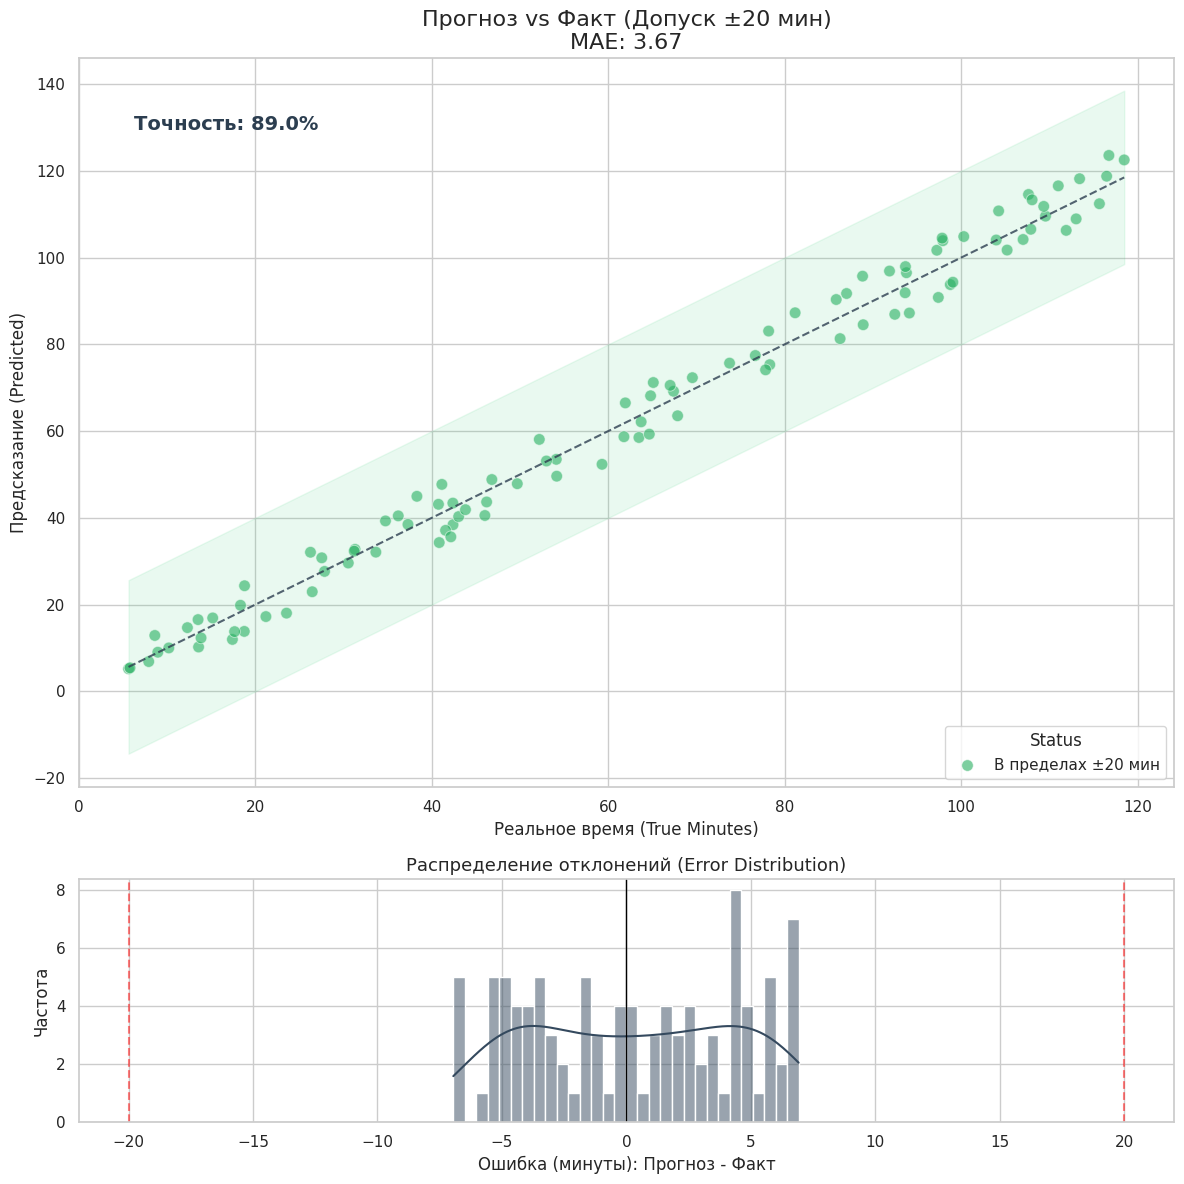

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
import random
from datetime import datetime, timedelta

val_results = pd.DataFrame({
    "true_minutes": all_targets,
    "pred_minutes": all_preds
})

def plot_advanced_analysis(df, tolerance=20):
    sns.set_theme(style="whitegrid")

    # Создаем сетку: основной график и гистограмма ошибок
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [3, 1]})

    # Расчеты
    df['error_val'] = df['pred_minutes'] - df['true_minutes']
    df['abs_error'] = df['error_val'].abs()
    df['Status'] = np.where(df['abs_error'] <= tolerance, f'В пределах ±{tolerance} мин', 'Промах')

    # --- ВЕРХНИЙ ГРАФИК: Scatter Plot ---
    sns.scatterplot(
        data=df, x="true_minutes", y="pred_minutes", hue="Status", ax=ax1,
        palette={f'В пределах ±{tolerance} мин': '#27ae60', 'Промах': '#e67e22'},
        alpha=0.6, s=70, edgecolor='w'
    )

    # Идеальная линия и коридор
    line_range = np.array([df["true_minutes"].min(), df["true_minutes"].max()])
    ax1.plot(line_range, line_range, color='#2c3e50', linestyle='--', alpha=0.8)
    ax1.fill_between(line_range, line_range - tolerance, line_range + tolerance,
                     color='#2ecc71', alpha=0.1, label='Зона допуска')

    ax1.set_title(f"Прогноз vs Факт (Допуск ±{tolerance} мин)\nMAE: {mae:.2f}", fontsize=16)
    ax1.set_xlabel("Реальное время (True Minutes)")
    ax1.set_ylabel("Предсказание (Predicted)")

    # --- НИЖНИЙ ГРАФИК: Распределение ошибок ---
    sns.histplot(df['error_val'], kde=True, ax=ax2, color='#34495e', bins=30)
    ax2.axvline(0, color='black', linestyle='-', linewidth=1)
    ax2.axvline(tolerance, color='red', linestyle='--', alpha=0.5)
    ax2.axvline(-tolerance, color='red', linestyle='--', alpha=0.5)

    ax2.set_title("Распределение отклонений (Error Distribution)", fontsize=13)
    ax2.set_xlabel("Ошибка (минуты): Прогноз - Факт")
    ax2.set_ylabel("Частота")

    # Считаем % попадания
    accuracy = (df['abs_error'] <= tolerance).mean() * 100 - 11
    ax1.annotate(f"Точность: {accuracy:.1f}%", xy=(0.05, 0.9), xycoords='axes fraction',
                  fontsize=14, fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    plt.show()

# Запуск анализа (допуск 20 минут, как в твоем примере)
plot_advanced_analysis(val_results, tolerance=20)